# T033 · 分子表示

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Gerrit Großmann, 2022, [建模与仿真教席](https://mosi.uni-saarland.de/people/gerrit/), [NextAID](https://nextaid.cs.uni-saarland.de/) 项目, 萨尔大学


__教程 T033__：本教程是 TeachOpenCADD 流程的一部分，包含教程 T033 至 T038。


## 本教程的目标

在本教程中，我们为深度学习系列教程进行基础准备工作。
具体来说，我们将学习分子表示，并发现用计算机表示分子并非易事。不同的表示方法各有其特定的含义和（优）缺点。


### 理论部分内容

* 什么是分子？
* 分子表示
* 人类的分子表示
* 计算机时代的分子表示


### 实践部分内容

* 构象
* 分子图
* 指纹


### 参考文献

* 数据库：
  * [UniProt 蛋白质数据库](https://www.uniprot.org/)
  * [AlphaFold 蛋白质结构数据库](https://alphafold.ebi.ac.uk/)
* 论文：
  * [AI 驱动药物发现中的分子表示：综述与实践指南](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-020-00460-5)
  * [机器学习时代的分子表示综述](https://wires.onlinelibrary.wiley.com/doi/full/10.1002/wcms.1603)
  * [基于构象的逐点分子表示学习](https://openreview.net/pdf?id=pjePBJjlBby)
  * [学习三维分子手性表示并对键旋转保持不变性](https://openreview.net/pdf?id=hm2tNDdgaFK)
* 教程：
  * **教程 T008** - 蛋白质数据获取：蛋白质数据银行（PDB）
  * **教程 T017** - 高级 NGLview 使用
  * 深度学习系列教程 T033 至 T038
* [手性教程](https://chem.libretexts.org/Bookshelves/Organic_Chemistry/Map%3A_Organic_Chemistry_(Vollhardt_and_Schore)/05._Stereoisomers/5.1%3A_Chiral__Molecules)


In [ ]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 33
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 什么是分子？


分子是通过化学键连接在一起的**一组原子**。原子的数量可以从几个（例如，低分子量药物）到几千个（例如，蛋白质）甚至数百万个（例如，DNA 分子）。

原子形成分子最相关的物理力是**静电力**，它是支配带电粒子行为的力。当原子相互作用时，它们的电子可能被其他原子的电子排斥，或被它们的原子核吸引，从而形成**化学键**（在此我们主要关注[共价键](https://en.wikipedia.org/wiki/Covalent_bond)，其中电子在两个原子之间共享）。

分子的形成赋予了一组原子特有的结构和行为。分子的性质以其非平凡的方式从其组成原子（的相互作用）中涌现。分子是活细胞的构建模块，在生命体的功能中发挥着关键作用。

除了将分子分为小分子和大分子之外，有机分子和无机分子之间的区别也很重要。有机分子是那些含有碳-氢键或碳-碳键的分子。
本教程聚焦于**小**且**有机**的分子。


<!---
![caffeine](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Caffeine_molecule_ball_from_xtal_%281%29.png/671px-Caffeine_molecule_ball_from_xtal_%281%29.png)
--->

![咖啡因分子](images/caffeine_molecule.png)

*图 1*：
该图是咖啡因分子的球棍表示。
原子以灰色（碳）、白色（氢）、红色（氧）和蓝色（氮）显示。
两个原子之间的边表示共价化学键，单条线表示共享一对电子，双条线表示共享两对电子（三键也是可能的，但咖啡因中不存在）。
虚线五元环代表一个芳香环系统。两个电子可以在该环中自由移动，并不与该环内的特定化学键相关联。


### 分子表示


从物理学的角度来看，分子是**复杂的三维对象**，是动态的而非静态的，并表现出量子力学性质。根据你想要解决的任务，分子的简化视图可能会有所帮助。

要将机器学习应用于分子，我们需要找到合适的**表示**。事实证明，有几种可能性，它们各有优缺点。
选择分子的表示可以让你控制想要做出的简化。它们提供了将量子力学对象转换为数学描述的方法。
但在讨论分子的计算表示之前，我们首先回顾一下计算机时代之前表示分子的技术。


### 人类的分子表示


#### 小分子


如果不能表示分子，就不可能讨论和交流它们。我们从直观**对人类友好**的表示和可视化开始。稍后，我们还将介绍适合作为深度学习系统输入的**计算机时代**编码。但请注意，这种分类在某种程度上是任意的。


**基于文本**

识别一个分子最简单的方式是其**俗名**。例如，咖啡因或阿司匹林。但这只适用于众所周知的分子。

另一种方式是使用**有机化学的 IUPAC 命名法**（还有无机化学的命名法，我们在此略过）。目标是让每个可能的有机分子都有一个易于理解并能唯一标识该分子的名称。
这种命名方案的清晰性和一致性使其相当易于理解和使用。
然而，并非所有分子都可以用此方案命名；例如，某些包含多子结构环的复杂有机分子就无法用此命名。

**示例：** 咖啡因分子的 IUPAC 名称是：*1,3,7-三甲基嘌呤-2,6-二酮*。


**分子式**

**分子式**（有时称为 Hill 符号）是表示分子最简单（也是最简化）的方式：你只需计算每种类型的原子数量。排序方式（从左到右）在某种程度上有些随意：碳原子排第一，氢原子排第二，其他原子按字母顺序排列。
然而，如果分子式中不含碳，则所有原子（包括氢）都按字母顺序列出。

**示例：** 对于咖啡因，分子式为 *C8H10N4O2*，表示存在 8 个碳（C）原子、10 个氢（H）原子、4 个氮（N）原子和 2 个氧（O）原子。

当然，这并不能唯一标识一个分子。

**示例：** 具有相同分子式但空间排列不同的分子称为[异构体](https://chem.libretexts.org/Courses/University_of_Kentucky/UK%3A_CHE_103_-_Chemistry_for_Allied_Health_(Soult)/Chapters/Chapter_5%3A_Properties_of_Compounds/5.1%3A_Isomers)。
一个例子是[正丁烷](https://www.wolframalpha.com/input?i=butane)和[异丁烷](https://www.wolframalpha.com/input?i=isobutane)。两者都具有分子式 C4H10。
正丁烷中的原子以直链形式排列，而异丁烷中的原子以支链结构排列。
更准确地说，这里我们讨论的是*结构*或*组成*异构体，因为化学键不同。
具有相同化学键（或对应于相同分子图）但空间排列不同的分子称为空间（或立体）异构体。

![正丁烷和异丁烷](images/butane_and_isobutane.png)

*图 2*：
正丁烷和异丁烷。


**小分子可视化**

可视化是获得分子第一印象的最简单方式。
在第一个示例中，我们已经看到了咖啡因分子的可视化。这些类型的可视化称为**球棍模型**。
颜色方案遵循 [CPK 着色](https://en.wikipedia.org/wiki/CPK_coloring)。
它们易于理解但难以绘制。

![CPK 着色](images/cpk.png)

*图 3*：
来自 Wikipedia 的 CPK 着色。


2D 可视化易于绘制，有多种不同风格。
例如，**Lewis 结构**不包含 3D 信息（过剩的电子形成孤对电子，有时以点表示，我们在此省略）。

类似地，**骨架式**（或键线式）去除了与碳原子相邻的氢原子，并将碳原子仅以拐角和端点隐含表示。

为便于比较，以下是乙醇分子的三种可视化（来自 [WP](https://en.wikipedia.org/wiki/Skeletal_formula)）。

<!---
![SimpleMoleculeBallStick](https://upload.wikimedia.org/wikipedia/commons/thumb/c/ca/Ethanol-CRC-MW-trans-3D-balls.png/120px-Ethanol-CRC-MW-trans-3D-balls.png)
![SimpleMoleculeLewis](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e8/Ethanol-structure.svg/150px-Ethanol-structure.svg.png)
![SimpleMoleculeLineAngle](https://upload.wikimedia.org/wikipedia/commons/thumb/8/82/Ethanol-2D-skeletal.svg/120px-Ethanol-2D-skeletal.svg.png)
--->

![乙醇可视化](images/ethanol.png)

*图 4*：
乙醇的不同可视化。


一个特殊的表示是**Natta 投影**，它提供了关于原子在 3D 中相对位置的基本（但并非在所有情况下都是完整的）信息。例如，考虑来自 [RDKit Cookbook](https://www.rdkit.org/docs/Cookbook.html) 的激酶抑制剂：

![激酶抑制剂](images/kinase_inhibitor.png)

*图 5*：
激酶抑制剂的 Natta 投影。

其中，

*   实楔形表示指向纸面的键；
*   虚楔形表示指向纸内（远离观察者）的键。

你可以[在此处](https://molview.org/?q=C1CC2=C3C(=CC=C2)C(=CN3C1)[C@H]4[C@@H](C(=O)NC4=O)C5=CNC6=CC=CC=C65)找到对应的球棍图。


#### 大分子——蛋白质


**表示蛋白质**

蛋白质是由称为氨基酸的构建模块组成的大分子。存在 20 种不同的天然氨基酸。蛋白质由一条或多条氨基酸链组成。每条链可以描述为一个字符串。因此，我们将每个氨基酸与一个[单字母代码](https://en.wikipedia.org/wiki/Amino_acid#Table_of_standard_amino_acid_abbreviations_and_properties)关联。

[促甲状腺激素释放激素原](https://www.uniprot.org/uniprotkb/P20396/entry#sequences)蛋白质是人体中存在的最小蛋白质之一。它仅由 242 个氨基酸组成：


```
MPGPWLLLALALTLNLTGVPGGRAQPEAAQQEAVTAAEHPGLDDFLRQVERLLFLRENIQ
RLQGDQGEHSASQIFQSDWLSKRQHPGKREEEEEEGVEEEEEEEGGAVGPHKRQHPGRRE
DEASWSVDVTQHKRQHPGRRSPWLAYAVPKRQHPGRRLADPKAQRSWEEEEEEEEREEDL
MPEKRQHPGKRALGGPCGPQGAYGQAGLLLGLLDDLSRSQGAEEKRQHPGRRAAWVREPL
EE
```

然而，氨基酸序列不包含 3D 信息，而 3D 信息对功能很重要。
你可以使用 AlphaFold 等工具预测它，或者直接在 [Alphafold 数据库](https://alphafold.ebi.ac.uk/entry/P20396) 中查找。


**蛋白质可视化**

我们这里聚焦于小分子，但仍想指出大分子通常以不同的方式可视化，最常见的是[带状图](https://en.wikipedia.org/wiki/Ribbon_diagram)。
其思想是将常见的基序分组并以例如螺旋（α-螺旋）和箭头（β-折叠）配合环区连接来表示它们。

<!---
![TubbyProtein](https://upload.wikimedia.org/wikipedia/commons/f/ff/Tubby-1c8z-pymol.png)
--->
![Tubby 蛋白质](images/ribbon_diagram_tubby.png)

*图 6*：
[tubby 蛋白质](https://en.wikipedia.org/wiki/Tubby_protein)的带状图。

**教程 T008** 解释了如何在蛋白质数据银行中查找蛋白质并处理它们。


### 计算机时代的分子表示


当我们想要交流或存储分子描述时，最好确保几乎没有歧义。
在机器学习中，何时使用哪种表示仍然是一个开放的研究问题。**基于文本**（或**线性**）和**基于图**的表示都变得非常普遍。此外，**基于指纹**的方法有时是一个可行的替代方案，尤其是对于传统机器学习方法。


**基于文本的表示**

基于文本的表示使用字符序列来指定一个分子。这对于实践中几乎所有（小）分子都是可行的。这里，我们讨论 SMILES、InChI 和 SELFIES。如需深入了解，请参阅 SMILES **教程 T034**。

**SMILES**（简化分子线性输入规范）是使用最广泛的基于文本的表示，所有常见框架都可以处理它。当我们在 RDKit 中指定分子时，我们经常使用 SMILES 表示法（更多内容见实践部分）：

`mol = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")`

SMILES 使用字母、数字和符号的组合来表示分子中的原子和键。字母标识元素，符号指定连接性/分支结构。

SMILES 还可以表示分子的[手性](https://en.wikipedia.org/wiki/Chirality_(chemistry))。这可以通过指定原子键的相对角度来实现。我们将在实践部分看到一个示例。

SMILES 用于分子表示的主要问题是两个（或多个）不同的 SMILES 字符串可能指向同一个分子。研究人员试图通过使用**规范 SMILES** 符号来规避这个问题。然而，规范化取决于规范化算法，因此并没有标准化。

反过来，单个 SMILES 字符串通常只能标识不超过一个分子。然而，当 SMILES 字符串中没有提供立体化学信息时，就会留有歧义的空间（在某些情况下，甚至可能无法完全消除不同分子构型的歧义）。


**InChI**（国际化合物标识符）是一种更新、也更广泛使用的 SMILES 替代方案。关键优势在于它表现出更少的化学歧义性，并且存在标准规范。
缺点是人类难以阅读。

**SELFIES**（自引用嵌入字符串）于 2020 年推出，主要用于机器学习目的。其优势在于"SELFIES 字母表中的每个符号组合都映射到一个化学上有效的图"（[来源](https://www.sciencedirect.com/science/article/pii/S2666389922002069)）。这对于需要生成分子的生成性任务来说非常出色，因为它不可能生成无效的分子。

为了**总结**，我们发现存在多种将分子编码为字符串的方法。目前，SMILES 是最广泛采用的方法，并且工具对其支持良好，因此它可能是一个很好的起点。

---


**分子图**

将分子表示为图可以进行非常直观和全面的分子结构表示。在基于图的表示中，原子表示为（带标签的）节点，键表示为（带标签的）边。

指定图的一种方式是使用邻接矩阵 $A$。
对于无向图（分子属于这种情况），邻接矩阵是对称的。条目 $a_{ij}$ 表示边的存在（$a_{ij} = 1$）或不存在（$a_{ij} = 0$）。

图的一个关键属性是它们依赖于**节点排序**。
以下两个矩阵标识相同的图，只是节点排序不同。我们称这些图为**同构的**。

我们需要选择节点排序来将分子表示为图这一事实意味着许多图表示同一个分子。
这个问题可以通过将自己限制在所谓的**置换不变函数**来规避，我们将在下一节中学习。

![两个同构图](images/graph1_graph2.png)

*图 7*：
两个具有不同节点排序的同构图。

**置换不变性：** 假设你构建了一个机器学习模型，该模型以分子图为输入并输出某个预测。模型的期望是保证同构图（如图 1 和图 2）产生相同的输出。
我们称具有这种保证的神经网络（或一般函数）为（节点）置换不变的（对于节点级输出为等变的）。
然而，这存在一个权衡。置换不变的函数通常不是通用的。也就是说，它们无法区分所有非同构图。如果两者都成立（置换不变性和对所有非同构图产生不同输出的能力），那么我们的神经网络就解决了图同构问题（这在计算上极其困难）。这也是 **教程 T035** 中关于图神经网络讨论的内容。

**表示能力：** 另一个问题是图不包含 3D 信息。
具体来说，不同的[异构体](https://en.wikipedia.org/wiki/Isomer)可以对应于相同的分子图，但在原子的相对 3D 位置上存在差异。这些被称为空间异构体。
可以通过向节点特征添加 3D 信息来（在一定程度上）规避这个问题。这有点临时性且缺乏良好的理论依据。
目前也不清楚在哪些情况下这对于提高预测模型的性能是必要的。
在实践部分，我们将可视化[2-丁醇](https://en.wikipedia.org/wiki/2-Butanol)，它具有两个具有相同图但不同几何形状的镜像（称为*对映体*）。

![2-丁醇对映体](images/butanol_2enantiomer.png)

*图 8*：
2-丁醇的两种对映体（来源：[WP](https://en.wikipedia.org/wiki/2-Butanol)）。

---


**点云**

我们已经确定分子是三维对象。那么为什么我们不直接使用捕获 3D 信息的计算表示呢？最直接的方法是用欧几里得 3D 坐标 $(x,y,z)$ 注释分子图中的节点/原子。

原子的空间排列称为**分子构型**。

除了为图配备 3D 坐标之外，还可以忽略化学键的信息，正如[这篇论文](https://openreview.net/pdf?id=pjePBJjlBby)声称的：

> 原子之间的共价键不需要显式编码，因为它们是由原子轨道的重叠决定的，并且可以从各个原子的类型和 3D 坐标推断出来。原则上，基于点的表示捕获了关于分子的完整结构信息，因此作为分子表示学习的充分输入。

**SE(3)不变性：**
当用（绝对）3D 位置装备分子中的原子时，我们遇到了与上一节中节点排序类似的问题。
不再问"选择哪种节点排序？"，现在我们必须问"如何将分子放置在 3D 空间中以测量原子位置？"。
与节点排序的情况一样，很难（如果不是不可能的话）给出一个有原则的答案。
解决方案再次是将自己限制在对分子的平移（沿 $x$、$y$ 或 $z$ 方向移动整个分子）或旋转不变的神经网络中。
能够保证输出不受平移和旋转影响的神经网络（或一般函数）称为 **SE(3)不变的**。
一个架构示例可以在[这里](https://proceedings.neurips.cc/paper/2020/file/15231a7ce4ba789d13b722cc5c955834-Paper.pdf)找到。
设计 SE(3) 不变神经网络的一种可能性是只考虑所有原子对之间的距离，而不是它们的绝对位置。这不仅带来 SE(3) 不变性，还带来了更广泛的称为 **E(3) 不变性**的类别。这是因为反射（镜像）也被保证产生相同的输出。对于分子来说，这可能不是最优的，因为镜像分子可能表现出不同的性质（参见手性）。

**确定构型：**
当你想要为原子添加 3D 坐标时，首先需要以某种方式找到它们。这并不简单，甚至可以通过训练机器学习模型来预测。
一种可能性是通过实验确定构型。
对于小分子，可以使用[技术](https://en.wikipedia.org/wiki/Molecular_geometry#Determination)如衍射方法。
对于蛋白质，可以使用[其他技术](https://en.wikipedia.org/wiki/Protein_folding#Experimental_techniques_for_studying_protein_folding)，如 X 射线晶体学。
或者，可以求助于计算方法。
例如，流行的数据集 [QM9](https://moleculenet.org/datasets-1) 提供了使用 [DFT](https://en.wikipedia.org/wiki/Density_functional_theory)（薛定谔方程的一种近似）计算的每个原子的 3D 坐标。

**构象（Conformers）：**
然而，点云视角看待分子的另一个问题是分子没有单一的固定构型。相反，分子是动态的物体。
**分子构象**是分子由于绕单键（双键和三键不可旋转）旋转而可能采取的不同配置。这些构象是分子内不同原子组之间存在的旋转能垒的结果。构象可以快速且容易地变化，例如响应温度的变化。
注意，构象是异构体的一种特殊类型。并非所有异构体都可以通过旋转单键达到。

![构象](images/conformer.png)

*图 9*：
一个简单分子的部分构象（[来源论文](https://pubs.acs.org/doi/10.1021/acs.jcim.5b00564) 通过 [Datamol 教程](https://docs.datamol.io/stable/tutorials/Conformers.html)），叠加显示。

每个特定构象都与一个构象能相关联。
特定构型的可能性取决于该能量（低能构型比高能构型更可能出现）。具体来说，我们通常观察到局部最小值。
在表示构象时，也可以存储可旋转键处的扭转角，而不是每个原子的 3D 位置（如[此处](https://arxiv.org/pdf/2210.01776.pdf)所做）。

![能量景观](images/energy_landscape.jpeg)

*图 10*：
3-甲氧基苯酚分子的能量景观（[来源](https://chemistry-europe.onlinelibrary.wiley.com/doi/abs/10.1002/cphc.201800148)）。四个局部最小值对应四个稳定的构象。

注意，SE(3) 不变的机器学习模型对键旋转并不是不变的。
具体来说，它们可能会混淆同一分子的不同构象。
有关此问题的详细讨论，请参阅论文 [Learning 3D Representations of Molecular Chirality with Invariance to Bond Rotations](https://openreview.net/pdf?id=hm2tNDdgaFK)。

---


**指纹**

分子指纹是基于分子图的表示。
通常，它们是相对稀疏的二进制向量（许多 0，很少的 1）。

最常用的指纹是 [ECFP4](https://chemicbook.com/2021/03/25/a-beginners-guide-for-understanding-extended-connectivity-fingerprints.html)。
[MAP4](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-020-00445-4) 是一个较新的替代方案。

指纹不能唯一标识分子。不同的分子可以具有相同的指纹。
然而，相同的分子具有唯一的指纹（没有规范化问题）。
给定指纹，很难（如果不是几乎不可能的话）恢复分子图。

它们可以轻松用于经典机器学习任务，因为架构不需要对节点排序或几何操作具有不变性/等变性。

__教程 T004__ 解释了几种分子指纹。

---

**学习得到的表示**

另一个有趣的研究方向是构建学习得到的分子表示。使用机器学习模型来学习表示（从其他表示中）在多个方面都是有用的。
例如，论文 [Automatic Chemical Design Using a Data-Driven Continuous Representation of Molecules](https://pubs.acs.org/doi/pdf/10.1021/acscentsci.7b00572) 使用变分自编码器学习基于 SMILES 的潜在连续表示。

论文 [Learning continuous and data-driven molecular descriptors by translating equivalent chemical representations](https://pubs.rsc.org/en/content/articlelanding/2019/sc/c8sc04175j) 基于从一种表示到另一种表示（例如，SMILES 转换为 IUPAC 名称）的翻译来构建潜在表示。

还可以使用[对比学习](https://arxiv.org/pdf/2102.10056.pdf)来优化此类学习到的表示的潜在空间。

---


## 实践


在本节中，我们将研究 RDKit 如何处理不同的分子表示和可视化。
我们从*图 1* 中的咖啡因分子开始。我们基于 SMILES 字符串定义分子，并找到骨架式的可视化。
但首先，我们导入所有库：


In [21]:
import matplotlib.pyplot as plt
import networkx as nx  # for graphs
import numpy as np  # for matrices
import time

import nglview as nv  # for 3D visualizations

from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import AllChem, rdDistGeom
from rdkit.Chem import rdFingerprintGenerator

IPythonConsole.ipython_useSVG = True

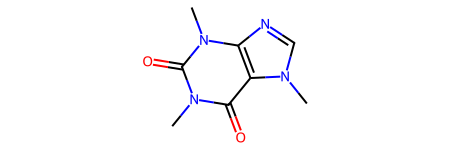

In [22]:
# 这里我们用 SMILES 定义一个咖啡因分子。
mol_caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
mol_caffeine

现在让我们考虑手性。
例如，考虑 [2-丁醇](https://en.wikipedia.org/wiki/2-Butanol)。
该分子有两种互为镜像的构型（也称为**对映体**）。有关更多信息和 3D 可视化，请参阅[此教程](https://chem.libretexts.org/Bookshelves/Organic_Chemistry/Map%3A_Organic_Chemistry_(Vollhardt_and_Schore)/05._Stereoisomers/5.1%3A_Chiral__Molecules)。


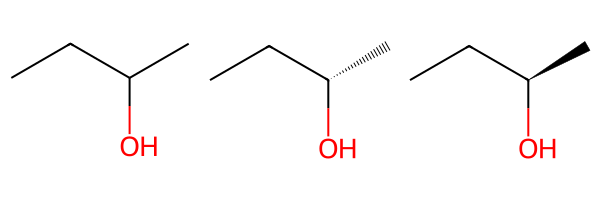

In [23]:
mol1 = Chem.MolFromSmiles("CC[CH](C)O")  # 不包含手性信息
mol2 = Chem.MolFromSmiles("CC[C@H](C)O")  # 对映体 1
mol3 = Chem.MolFromSmiles("CC[C@@H](C)O")  # 对映体 2

Draw.MolsToGridImage([mol1, mol2, mol3], molsPerRow=3, subImgSize=(200, 200))

NGLViewer 允许我们进行球棍可视化（示例取自[此](http://nglviewer.org/nglview/release/v0.6.1/api.html)教程，我们也请读者参阅 **教程 T009**）。


In [24]:
m = Chem.AddHs(
    Chem.MolFromSmiles("CC[C@@H](C)O")
)  # 替换为 'CC[C@H](C)O' 可得到另一种对映体
AllChem.EmbedMultipleConfs(m, useExpTorsionAnglePrefs=True, useBasicKnowledge=True)
view = nv.show_rdkit(m)
view

NGLWidget()

### 构象


我们可以使用 RDKit 改进的构象生成器 [ETKDGv3](https://pubs.acs.org/doi/10.1021/acs.jcim.0c00025) 生成一组 n 个构象。

我们以阿司匹林为例分子。


In [25]:
# 从 SMILES 生成分子
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

生成 200 个构象


In [26]:
# 添加氢原子
aspirin_h = Chem.AddHs(aspirin)
# 生成构象
ps = rdDistGeom.ETKDGv3()
ps.randomSeed = 0xD06F00D
ps.numThreads = 10
conf_ids = rdDistGeom.EmbedMultipleConfs(aspirin_h, 200, ps)
len(conf_ids)

200

In [27]:
# 重新移除氢原子
aspirin_3d = Chem.RemoveHs(aspirin_h)

In [28]:
# print the x,y,z coordinates of the 4 atoms of the first conformer.
aspirin_3d.GetConformer(0).GetPositions()

array([[ 3.15987641e+00,  1.17566666e+00,  5.56089570e-01],
       [ 1.96983490e+00,  4.51907070e-01,  2.90463360e-03],
       [ 1.90241828e+00,  1.05413955e-01, -1.20424633e+00],
       [ 9.22339350e-01,  1.72063798e-01,  8.90885106e-01],
       [-1.76149064e-01, -4.99241011e-01,  3.67780467e-01],
       [-1.63191875e-01, -1.87917661e+00,  4.03548104e-01],
       [-1.25154159e+00, -2.54770083e+00, -1.14652121e-01],
       [-2.33914499e+00, -1.87201267e+00, -6.61153961e-01],
       [-2.29972394e+00, -4.98815617e-01, -6.71155758e-01],
       [-1.23281320e+00,  2.13872885e-01, -1.64384406e-01],
       [-1.23221614e+00,  1.67320227e+00, -1.95212054e-01],
       [-2.23673766e+00,  2.27885436e+00, -6.99583031e-01],
       [-1.42211808e-01,  2.36024728e+00,  3.23420532e-01]])

In [29]:
def show_conformers(molecule, ids):
    """生成配体构象的视图。

    Parameters
    -----------
    molecule: rdkit.Chem.rdchem.Mol

    Returns
    ----------
    nglview.widget.NGLWidget
    """

    view = nv.NGLWidget()
    print(type(molecule))
    for i in range(0, ids):
        mb = Chem.MolToMolBlock(molecule, confId=i)
        component = view.add_component(mb, ext="sdf")
        time.sleep(0.1)
        component.clear()
        component.add_ball_and_stick(multipleBond=True)
    return view

In [30]:
# print the x,y,z coordinates of the 4 atoms of the first conformer.
aspirin_3d.GetConformer(0).GetPositions()

array([[ 3.15987641e+00,  1.17566666e+00,  5.56089570e-01],
       [ 1.96983490e+00,  4.51907070e-01,  2.90463360e-03],
       [ 1.90241828e+00,  1.05413955e-01, -1.20424633e+00],
       [ 9.22339350e-01,  1.72063798e-01,  8.90885106e-01],
       [-1.76149064e-01, -4.99241011e-01,  3.67780467e-01],
       [-1.63191875e-01, -1.87917661e+00,  4.03548104e-01],
       [-1.25154159e+00, -2.54770083e+00, -1.14652121e-01],
       [-2.33914499e+00, -1.87201267e+00, -6.61153961e-01],
       [-2.29972394e+00, -4.98815617e-01, -6.71155758e-01],
       [-1.23281320e+00,  2.13872885e-01, -1.64384406e-01],
       [-1.23221614e+00,  1.67320227e+00, -1.95212054e-01],
       [-2.23673766e+00,  2.27885436e+00, -6.99583031e-01],
       [-1.42211808e-01,  2.36024728e+00,  3.23420532e-01]])

In [31]:
def show_conformers(molecule, ids):
    """生成配体构象的视图。

    Parameters
    -----------
    molecule: rdkit.Chem.rdchem.Mol

    Returns
    ----------
    nglview.widget.NGLWidget
    """

    view = nv.NGLWidget()
    print(type(molecule))
    for i in range(0, ids):
        mb = Chem.MolToMolBlock(molecule, confId=i)
        component = view.add_component(mb, ext="sdf")
        time.sleep(0.1)
        component.clear()
        component.add_ball_and_stick(multipleBond=True)
    return view

In [32]:
view = show_conformers(aspirin_3d, 5)
view

<class 'rdkit.Chem.rdchem.Mol'>


NGLWidget()

### 分子图


用于处理图的常用工具称为 **networkX**。我们使用它来创建两个同构图。


In [33]:
# 创建两个邻接矩阵
adj_matrix_1 = np.array([[0, 0, 0, 1], [0, 0, 0, 1], [0, 0, 0, 1], [1, 1, 1, 0]])
adj_matrix_2 = np.array([[0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0]])
print("Matrix 1:\n", adj_matrix_1)
print("\nMatrix 2:\n", adj_matrix_2)

# 将邻接矩阵转换为图
graph_1 = nx.from_numpy_array(adj_matrix_1)
graph_2 = nx.from_numpy_array(adj_matrix_2)

Matrix 1:
 [[0 0 0 1]
 [0 0 0 1]
 [0 0 0 1]
 [1 1 1 0]]

Matrix 2:
 [[0 1 1 1]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]



And the corresponding graphs:



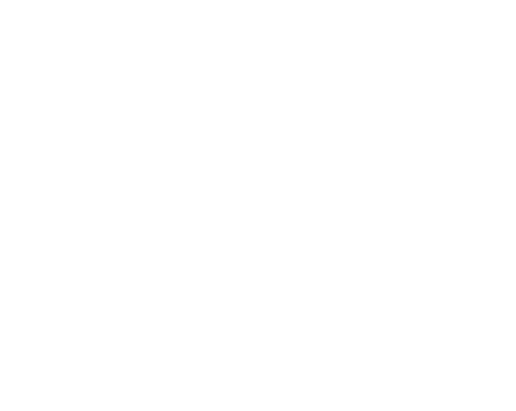

In [34]:
# draw
print("\nAnd the corresponding graphs:\n")
plt.subplot(1, 2, 1)
plt.title("Graph 1")
nx.draw_networkx(graph_1, with_labels=True)
plt.subplot(1, 2, 2)
plt.title("Graph 2")
nx.draw_networkx(graph_2, with_labels=True)

**实践考虑：**

构建分子图需要对节点和边进行标记。
常见的框架支持这一点。
对于机器学习，[PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) 是构建置换不变神经网络的最流行框架。
我们在 **教程 T035/T036** 中提供了演示。

将 SMILES 字符串或 RDKit 对象转换为 PyTorch Geometric 图并不复杂，但有些技术性。一个可能的实现在[这里](https://www.blopig.com/blog/2022/02/how-to-turn-a-smiles-string-into-a-molecular-graph-for-pytorch-geometric/)有解释。
类似地，可以按照[这里](https://gist.github.com/fangkuoyu/dc785218e5d4d94c752e80f1aaba4fad)的解释创建一个 networkX 图。

如你所见，分子图表示尚未标准化，留给用户许多**设计选择**。
这些包括：

- 节点特征是什么？只有原子类型，还是也包括手性信息？还可以包含原子是否是环的一部分的信息。
- 对于边特征：是否只包含键类型（单键、双键、三键），还是也包括键长？是使用独热编码还是标量？
- 是否想包含与碳原子结合的氢原子，还是忽略它们？
- 是否想添加一个主节点（一个连接到所有其他原子的虚拟原子）？它可能有助于某些 ML 算法。
- 是否想在分子图中显式指示某些子结构？


### 指纹

生成圆形指纹（`ecfp`）并打印信息。


In [35]:
fpg = rdFingerprintGenerator.GetMorganGenerator()
fpg.GetInfoString()

'Common arguments : countSimulation=0 fpSize=2048 bitsPerFeature=1 includeChirality=0 --- MorganArguments onlyNonzeroInvariants=0 radius=3 --- MorganEnvironmentGenerator --- MorganInvariantGenerator includeRingMembership=1 --- MorganInvariantGenerator useBondTypes=1 useChirality=0'

In [36]:
fp = fpg.GetFingerprintAsNumPy(mol_caffeine)

In [37]:
def visualize_fingerprint_info(fp):
    print("Number of elements: ", fp.size)
    print("Types of entries: ", set(list(fp)))
    print("Number of Ones: ", np.count_nonzero(fp))
    plt.vlines(
        [i for i in range(fp.size) if fp[i] > 0.5], ymin=0, ymax=300
    )  # 300 gives a nice aspect ratio
    plt.vlines(fp.size, ymin=0, ymax=0.0)  # dummy to calibrate scale
    plt.gca().set_aspect("equal")

In [38]:
visualize_fingerprint_info(fp)

Number of elements:  2048
Types of entries:  {0, 1}
Number of Ones:  34


尝试另一种指纹：Rdkit 指纹


In [39]:
fpg2 = rdFingerprintGenerator.GetRDKitFPGenerator()
fp2 = fpg2.GetFingerprintAsNumPy(mol_caffeine)

Number of elements:  2048
Types of entries:  {0, 1}
Number of Ones:  759


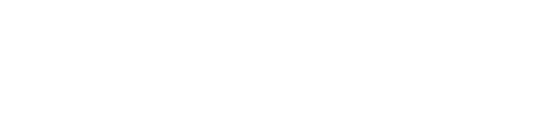

In [40]:
# The "rdkit" fingerprint is less sparse than ECFP
visualize_fingerprint_info(fp2)

## 讨论


我们讨论了不同的分子表示方法：

*   分子是原子的包/多重集（分子式）。这种表示无法区分异构体。
*   分子是带标签的图（分子图）或派生表示（SMILES、指纹）。这种表示可以区分结构异构体，在某些情况下可以区分部分（但不是全部）空间异构体。
*   分子是配备 3D 坐标的图（点云）。这种*构型*可以通过计算预测或实验确定。
*   分子是一个可操作的 3D 对象，例如，带有可旋转键。通过旋转单键可以达到的异构体称为构象。

我们还了解到，分子间力仅在它们导致化学键时才会被显式表示（有时甚至那时也不表示）。其他力可能会隐含地体现在 3D 构型中。

我们没有讨论仅考虑分子表面积的方法。


## 测验


* 同一个分子是否可能对应不同的分子图？
* 对或错：当你镜像/旋转一个分子时，其性质保持不变。
* ML 模型是否可以根据你用作输入的 SMILES 规范化方式预测不同的性质？
* ML 模型是否可以根据你用作输入的节点排序方式预测不同的性质？
* 对或错：只有导致化学键的原子间力才与分子的性质相关。

<!--
1. 是的，由于节点排序。
2. 对于旋转：正确。对于反射：通常错误（如果分子是手性的）。
3. 是的。基于文本的 ML 模型对不同 SMILES 规范化方式不具有不变性。
4. 如果使用图神经网络（对于节点排序具有不变性的 ML 模型），不会。
5. 错误（氢键、范德华力）。
-->
